# EDA 2 — os datasets juntos

O conjunto que o modelo do jogo vai usar: equilíbrio das classes em treino, validação e teste, de onde vem cada classe, período, formato e o teste de atalho. O perfil de cada base está em `eda_1_datasets.ipynb`.

**Regra para não vazar o teste:** composição e equilíbrio são contados em todos os splits; o conteúdo (formato, fontes) é explorado só no treino.

| Dataset | Linhas | Verdadeiras | Enganosas (meio) | Falsas | Período | O que é |
|---|---:|---:|---:|---:|---|---|
| Fake.br | 7.185 | 3.585 | 0 | 3.600 | 2016–2018 | pares falsa × verdadeira do mesmo assunto (NILC/USP); só texto longo |
| FakeRecogna | 4.382 | 1.917 | 0 | 2.465 | 2019–2021 | boatos do Boatos.org × matérias do G1, UOL e Extra (UNESP), texto recoletado |
| FakeTrue.Br | 2.142 | 1.330 | 0 | 812 | 2018–2022 (maioria) | pares Boatos.org × G1/Folha/UOL do mesmo assunto; texto em minúsculas |
| Fact Check API | 10.341 | 94 | 3.122 | 7.125 | 2018–2026 | alegações com veredito de 10 agências brasileiras (Google Fact Check Tools) |
| FakenewsBR (agências) | 16.729 | 603 | 555 | 15.571 | 2016–2026 | alegações checadas por agências (e-farsas, G1 Fato ou Fake, Lupa...); falsos amostrados |
| FakenewsBR (mensagens) | 7.082 | 3.928 | 3 | 3.151 | 2018 e 2020 | mensagens de WhatsApp (eleição 2018) e de COVID anotadas; sem veredito |
| Portais | 21.222 | 21.222 | 0 | 0 | 2018–2026 | matérias de 9 portais de linhas editoriais variadas; verdadeiras por suposição |
| **Total** | **69.083** | **32.679** | **3.680** | **32.724** | | |

Linhas = registros no `dataset.jsonl`, depois de tirar duplicatas. Uso no modelo do jogo
(protocolo B, `split_produto`), depois do equilíbrio:

| Split | Verdadeiras | Enganosas | Falsas | Regra |
|---|---:|---:|---:|---|
| `treino` | 12.512 | 1.541 | 12.512 | pareadas 80%; checagens e portais até 2023; mensagens |
| `validacao` | 1.446 | 964 | 1.446 | pareadas 10%; checagens e portais de 2024 |
| `teste` | 1.638 | 1.092 | 1.638 | pareadas 10%; checagens e portais de 2025 em diante |

O que sobra no equilíbrio vira `reserva` (32.164 registros, quase todos portais e falsos da
FakenewsBR); sem data, anteriores a 2016 ou quase-duplicatas viram `fora` (2.130).
Contagem de 05/10/2026, gerada por `pesquisa/dados/preparar_dados.py`.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLASSES = ["verdadeiro", "enganoso", "falso"]
CORES = {"verdadeiro": "#2a78d6", "enganoso": "#e0a030", "falso": "#eb6834"}
TINTA_2 = "#52514e"
SPLITS = ["treino", "validacao", "teste"]
DATASETS = ["Fake.br", "FakeRecogna", "FakeTrue.Br", "Fact Check API",
            "FakenewsBR (agências)", "FakenewsBR (mensagens)", "Portais"]
MENSAGENS = {"FakeWhatsApp.BR_2018", "COVID19.BR"}
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.6), "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.edgecolor": "#b8b7b0",
    "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False,
})
pd.set_option("display.max_colwidth", 120)

df = pd.read_json(RAIZ / "data" / "processed" / "dataset.jsonl", lines=True, dtype={"par_id": "Int64"})
NOMES = {"fakebr": "Fake.br", "fakerecogna": "FakeRecogna", "faketrue": "FakeTrue.Br",
         "factcheck": "Fact Check API", "verdadeiras": "Portais"}
df["dataset"] = df.base.map(NOMES)
fnb = df.base.eq("fakenewsbr")
df.loc[fnb & df.fonte.isin(MENSAGENS), "dataset"] = "FakenewsBR (mensagens)"
df.loc[fnb & ~df.fonte.isin(MENSAGENS), "dataset"] = "FakenewsBR (agências)"
df["data"] = pd.to_datetime(df["data"], errors="coerce")
df["ano"] = df.data.dt.year.astype("Int64")
df["tem_curto"] = df.texto_curto.notna()
curto = df.texto_curto.fillna("")
palavras = df.texto.str.findall(r"\w+")
df["palavras"] = palavras.str.len()
df["palavras_curto"] = curto.str.split().str.len()
df["% caixa alta"] = palavras.apply(lambda p: 100 * sum(w.isupper() and len(w) > 1 for w in p) / max(len(p), 1))
df["tem !"] = df.texto.str.contains("!", regex=False)
df["curto termina com ponto"] = curto.str.rstrip().str.endswith(".")
df["curto começa com vídeo/foto"] = curto.str.match(r"\W*(v[íi]deo|foto)", case=False)
df["curto em minúsculas"] = curto.ne("") & curto.eq(curto.str.lower())
print(f"{len(df):,} registros".replace(",", "."))
ativos = df[df.split_produto.isin(SPLITS)]
treino = ativos[ativos.split_produto == "treino"]

69.083 registros


## 1. Equilíbrio por split

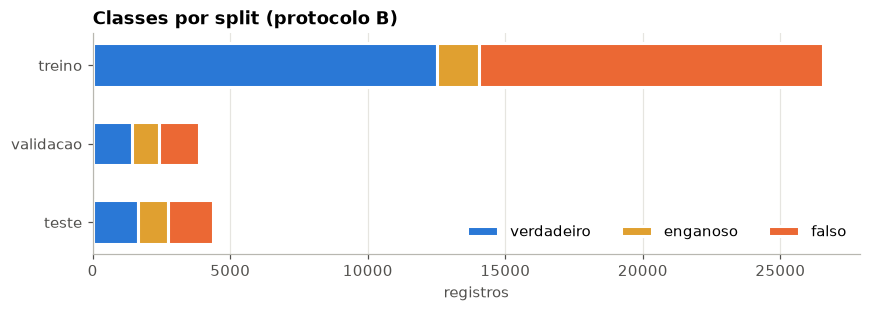

veracidade,verdadeiro,enganoso,falso,% verdadeiro,% enganoso,% falso
split_produto,,,,,,
treino,12512,1541,12512,47.1,5.8,47.1
validacao,1446,964,1446,37.5,25.0,37.5
teste,1638,1092,1638,37.5,25.0,37.5


In [2]:
comp = ativos.groupby(["split_produto", "veracidade"]).size().unstack(fill_value=0).reindex(index=SPLITS, columns=CLASSES)
fig, ax = plt.subplots(figsize=(9, 2.6))
esquerda = np.zeros(len(comp))
for c in CLASSES:
    ax.barh(comp.index, comp[c], left=esquerda, color=CORES[c], label=c, height=0.55, edgecolor="white", linewidth=2)
    esquerda += comp[c].values
ax.invert_yaxis(); ax.legend(loc="lower right", ncol=3); ax.grid(axis="y", visible=False)
ax.set_title("Classes por split (protocolo B)"); ax.set_xlabel("registros")
plt.show()
comp.assign(**{f"% {c}": (100 * comp[c] / comp.sum(axis=1)).round(1) for c in CLASSES})

Treino com verdadeiros e falsos iguais e ~5% de enganosos; validação e teste com todos os enganosos e ~38/25/38. O enganoso é raro em todas as bases: o modelo ordinal e os pesos por classe compensam, e a validação e o teste mostram se ele aprende o meio.

## 2. De que dataset vem cada classe

In [3]:
(ativos.pivot_table(index=["split_produto", "dataset"], columns="veracidade", values="id", aggfunc="size", fill_value=0)
 .reindex(columns=CLASSES).reindex(SPLITS, level=0))

veracidade                            verdadeiro  enganoso  falso
split_produto dataset                                            
treino        Fact Check API                  72      1244   3516
              Fake.br                       2864         0   2877
              FakeRecogna                   1536         0   1960
              FakeTrue.Br                   1057         0    645
              FakenewsBR (agências)          299       294    363
              FakenewsBR (mensagens)        3928         3   3151
              Portais                       2756         0      0
validacao     Fact Check API                   7       804    863
              Fake.br                        375         0    259
              FakeRecogna                    187         0    164
              FakeTrue.Br                    138         0     59
              FakenewsBR (agências)           50       160    101
              Portais                        689         0      0
teste         Fact Check API                  15      1069   1202
              Fake.br                        345         0    163
              FakeRecogna                    192         0    138
              FakeTrue.Br                    133         0     42
              FakenewsBR (agências)           81        23     93
              Portais                        872         0      0

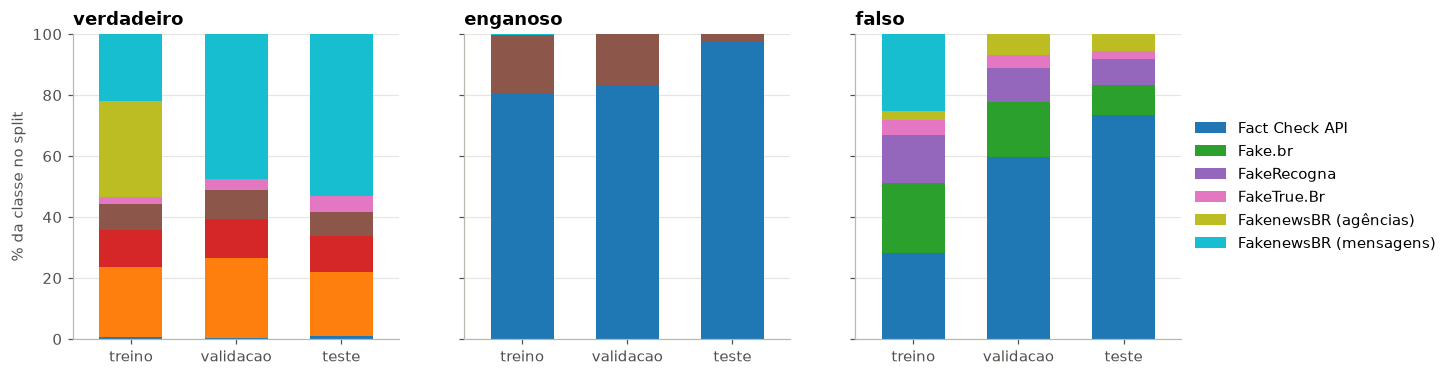

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, c in zip(axes, CLASSES):
    s = ativos[ativos.veracidade == c].pivot_table(index="split_produto", columns="dataset", values="id", aggfunc="size", fill_value=0).reindex(SPLITS)
    s = s.div(s.sum(axis=1), axis=0).mul(100)
    s.plot.bar(stacked=True, ax=ax, legend=False, width=0.6, colormap="tab10")
    ax.set_title(c); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
axes[0].set_ylabel("% da classe no split")
axes[-1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

Os enganosos vêm só da Fact Check API e das agências da FakenewsBR. Na validação e no teste, os verdadeiros recentes vêm sobretudo dos portais e dos pares sorteados; os falsos recentes, da Fact Check API.

## 3. Origem do rótulo e peso

In [5]:
pesos = {"agencia": 1.0, "curadoria": 1.0, "portal": 0.7, "mensagem": 0.7}
o = ativos.groupby(["origem_rotulo", "split_produto", "veracidade"]).size().unstack(["split_produto", "veracidade"], fill_value=0)
o = o.reindex(columns=pd.MultiIndex.from_product([SPLITS, CLASSES]), fill_value=0)
o.insert(0, "peso", o.index.map(pesos))
o

peso     treino                 validacao                 \
                   verdadeiro enganoso falso verdadeiro enganoso falso   
origem_rotulo                                                            
agencia        1.0        371     1538  6484         57      964  1187   
curadoria      1.0       2864        0  2877        375        0   259   
mensagem       0.7       3928        3  3151          0        0     0   
portal         0.7       5349        0     0       1014        0     0   

                   teste                 
              verdadeiro enganoso falso  
origem_rotulo                            
agencia               96     1092  1475  
curadoria            345        0   163  
mensagem               0        0     0  
portal              1197        0     0

Só 3% dos verdadeiros do treino são checados por agência; o resto é curadoria (Fake.br), portal ou mensagem. Os falsos e enganosos são quase todos de agência.

## 4. Período

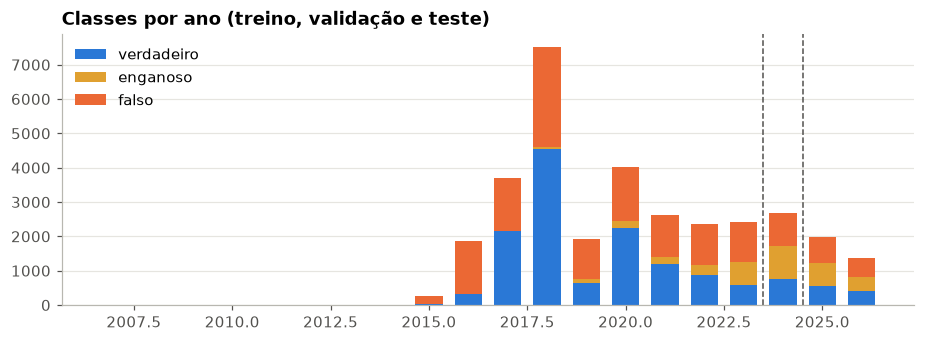

ano,2007,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
veracidade,,,,,,,,,,,,,,,,,,,
verdadeiro,1,3,6,5,9,7,12,40,320,2151,4548,630,2242,1196,885,592,746,564,404
enganoso,0,0,0,0,0,0,0,0,11,3,44,137,216,203,277,649,964,674,418
falso,0,0,0,0,1,1,1,213,1528,1541,2926,1146,1570,1217,1189,1173,964,750,545


In [6]:
por_ano = ativos.groupby(["ano", "veracidade"]).size().unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0)
fig, ax = plt.subplots(figsize=(10, 3.2))
base = np.zeros(len(por_ano))
for c in CLASSES:
    ax.bar(por_ano.index.astype(int), por_ano[c], bottom=base, color=CORES[c], label=c, width=0.7)
    base += por_ano[c].values
ax.axvline(2023.5, color=TINTA_2, ls="--", lw=1); ax.axvline(2024.5, color=TINTA_2, ls="--", lw=1)
ax.set_title("Classes por ano (treino, validação e teste)"); ax.legend(loc="upper left"); ax.grid(axis="x", visible=False)
plt.show()
por_ano.T

Os pares sorteados (Fake.br, FakeRecogna, FakeTrue.Br) trazem anos antigos para a validação e o teste, e as checagens e os portais trazem 2024 e 2025+. Nos anos em que uma classe domina, o assunto da época pode virar pista: é o que a queda entre a validação e o teste vai medir.

## 5. Texto curto: quanto do conjunto já está no formato do modelo

In [7]:
(ativos.groupby(["split_produto", "veracidade"]).tem_curto.mean().mul(100).round(1)
 .unstack().reindex(index=SPLITS, columns=CLASSES).rename_axis(columns="% com texto curto"))

% com texto curto,verdadeiro,enganoso,falso
split_produto,,,
treino,46.0,99.9,57.7
validacao,64.5,100.0,82.1
teste,70.8,100.0,90.0


Fake.br, as verdadeiras do FakeTrue.Br e ~75% das mensagens não têm texto curto. Para o modelo de frases curtas, eles precisam da extração de afirmações pela LLM (o mesmo prompt usado em produção); sem ela, o treino em texto curto perde boa parte dos verdadeiros.

## 6. Formato por classe (só treino)

In [8]:
cols = ["palavras", "% caixa alta", "tem !", "curto termina com ponto", "curto começa com vídeo/foto", "curto em minúsculas"]
f = treino.groupby("veracidade")[cols].agg({c: ("median" if c == "palavras" else "mean") for c in cols}).reindex(CLASSES)
f.iloc[:, 2:] *= 100
f.round(1)

,palavras,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,,
verdadeiro,293.0,3.4,17.0,2.1,0.4,0.3
enganoso,13.0,2.1,3.2,11.7,11.0,0.3
falso,56.0,5.5,31.3,21.0,5.3,5.3


In [9]:
(treino.groupby(["dataset", "veracidade"])[["curto termina com ponto", "curto em minúsculas", "tem !"]].mean().mul(100).round(1)
 .unstack().reindex(DATASETS))

curto termina com ponto                   \
veracidade                            enganoso falso verdadeiro   
dataset                                                           
Fake.br                                    NaN   0.0        0.0   
FakeRecogna                                NaN  97.8        0.0   
FakeTrue.Br                                NaN   0.0        0.0   
Fact Check API                            13.7  13.1       19.4   
FakenewsBR (agências)                      3.4   2.8        0.3   
FakenewsBR (mensagens)                     0.0   7.5        6.3   
Portais                                    NaN   NaN        0.0   

                       curto em minúsculas                      tem !        \
veracidade                        enganoso  falso verdadeiro enganoso falso   
dataset                                                                       
Fake.br                                NaN    0.0        0.0      NaN  32.8   
FakeRecogna                            NaN    0.0        0.4      NaN  54.9   
FakeTrue.Br                            NaN  100.0        0.0      NaN  47.6   
Fact Check API                         0.2    0.3        0.0      1.8   2.6   
FakenewsBR (agências)                  0.7    2.8        8.0      8.8  12.9   
FakenewsBR (mensagens)                 0.0    0.0        0.2     33.3  46.2   
Portais                                NaN    NaN        0.1      NaN   NaN   

                                   
veracidade             verdadeiro  
dataset                            
Fake.br                      16.8  
FakeRecogna                   5.5  
FakeTrue.Br                  13.2  
Fact Check API                1.4  
FakenewsBR (agências)        19.1  
FakenewsBR (mensagens)       29.1  
Portais                       7.8

O ponto final no texto curto vem quase todo das falsas do FakeRecogna, e as minúsculas, das falsas do FakeTrue.Br: são pistas de **como cada base foi montada**, não de veracidade.

## 7. Teste de atalho

Uma regressão logística que **não lê o conteúdo**, só a forma do texto curto (tamanho, pontuação, caixa alta, primeira palavra). Se ela separa bem as classes, o classificador de verdade também vai aprender a forma. A AUC dela é o piso que o classificador precisa superar com folga.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

com_curto = ativos[ativos.tem_curto].copy()
t = com_curto.texto_curto
pal = t.str.findall(r"\w+")
X = pd.DataFrame({
    "palavras": pal.str.len(),
    "% caixa alta": pal.apply(lambda p: 100 * sum(w.isupper() and len(w) > 1 for w in p) / max(len(p), 1)),
    "!": t.str.contains("!", regex=False), "?": t.str.contains("?", regex=False),
    "aspas": t.str.contains('["“”]'), "dois-pontos": t.str.contains(":", regex=False),
    "número": t.str.contains(r"\d"), "termina com ponto": t.str.rstrip().str.endswith("."),
    "começa com maiúscula": t.str[:1].str.isupper(), "tudo minúsculo": t.eq(t.str.lower()),
}, index=com_curto.index).astype(float)
primeira = t.str.extract(r"^\W*(\w+)")[0].str.lower()
top = primeira[com_curto.split_produto == "treino"].value_counts().head(30).index
X = X.join(pd.get_dummies(primeira.where(primeira.isin(top), "outra"), prefix="1a").astype(float))
y = com_curto.veracidade
eh_treino = com_curto.split_produto == "treino"
escala = StandardScaler().fit(X[eh_treino])
modelo = LogisticRegression(max_iter=2000, class_weight="balanced").fit(escala.transform(X[eh_treino]), y[eh_treino])
linhas = []
for split in SPLITS:
    m = com_curto.split_produto == split
    p = modelo.predict_proba(escala.transform(X[m]))
    linha = {"split": split, "registros": int(m.sum()),
             "AUC macro": roc_auc_score(y[m], p, multi_class="ovr", average="macro", labels=modelo.classes_)}
    for i, c in enumerate(modelo.classes_):
        linha[f"AUC {c} × resto"] = roc_auc_score(y[m] == c, p[:, i])
    linhas.append(linha)
print("0,5 = acaso; 1,0 = separa tudo só pela forma")
pd.DataFrame(linhas).set_index("split").round(3)

0,5 = acaso; 1,0 = separa tudo só pela forma


,registros,AUC macro,AUC enganoso × resto,AUC falso × resto,AUC verdadeiro × resto
split,,,,,
treino,14511,0.746,0.679,0.776,0.783
validacao,3084,0.649,0.587,0.656,0.704
teste,3727,0.635,0.581,0.612,0.711


In [11]:
pesos_atalho = pd.DataFrame(modelo.coef_.T, index=X.columns, columns=modelo.classes_)
pesos_atalho.loc[pesos_atalho.abs().max(axis=1).sort_values(ascending=False).index[:12]].round(2)

,enganoso,falso,verdadeiro
palavras,-0.65,0.32,0.33
termina com ponto,-0.04,0.56,-0.52
tudo minúsculo,-0.22,0.51,-0.29
1a_vídeo,0.16,0.11,-0.28
dois-pontos,-0.09,-0.16,0.26
1a_covid,-0.25,0.05,0.19
1a_coronavírus,-0.23,0.04,0.19
1a_para,-0.23,0.08,0.15
1a_este,0.08,0.12,-0.20
começa com maiúscula,0.19,-0.02,-0.18


## 8. Fontes que só têm uma classe (só treino)

In [12]:
por_fonte = treino.groupby("fonte").veracidade.agg(["nunique", "size"])
uma = por_fonte[por_fonte["nunique"] == 1]
print(f"{len(uma)} de {len(por_fonte)} fontes têm uma classe só; elas somam "
      f"{100 * uma['size'].sum() / len(treino):.0f}% do treino")
treino[treino.fonte.isin(uma.index)].groupby("veracidade").fonte.value_counts().groupby(level=0).head(5).rename("registros").to_frame()

63 de 81 fontes têm uma classe só; elas somam 38% do treino


registros
veracidade fonte                             
falso      diariodobrasil.org            2661
           boatos.org                    2605
           afolhabrasil.com.br            140
           thejornalbrasil.com.br          56
           ceticismopolitico.com           13
verdadeiro politica.estadao.com.br        593
           uol.com.br                     397
           oantagonista.com.br            356
           brasildefato.com.br            354
           poder360.com.br                332

63 das 81 fontes do treino têm uma classe só, e somam 38% dos registros. A fonte não entra no modelo, mas o estilo de cada fonte entra no texto. Por isso as métricas da avaliação saem por fonte e por dataset, e não só a média.

## 9. Conclusões

1. **Equilíbrio**: treino com verdadeiros = falsos e ~5% de enganosos; validação e teste em ~38/25/38. O enganoso é o gargalo de todas as bases.
2. **Formato**: cada base tem a sua marca (ponto final no FakeRecogna, minúsculas no FakeTrue.Br, manchete nos portais). Só pela forma, sem ler o conteúdo, o teste de atalho chega a AUC macro 0,75 no treino e ~0,64 na validação e no teste: é o piso que o classificador precisa superar com folga. A padronização pela LLM, igual no treino e no uso, deve derrubar essa AUC.
3. **Texto curto**: boa parte dos verdadeiros não tem texto curto; a extração de afirmações pela LLM é pré-requisito para treinar em frases curtas.
4. **Rótulo**: só 3% dos verdadeiros do treino são checados; o resto é curadoria, portal ou mensagem, com pesos menores para portal e mensagem.
5. **Avaliação**: reportar por split, por dataset e por fonte; a fatia de checagens (Fact Check API e agências) mostra o desempenho sem o atalho de formato.